In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [4]:
# Load Dataset
df = pd.read_csv("agriculture_yield_dataset.csv")
# Q1. Dataset Overview
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

In [5]:
# Q2. Data Types and Missing Values
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [6]:
# Q3. Descriptive Statistics
print("\nSummary Statistics:")
print(df.describe())

numeric_cols = df.select_dtypes(include=np.number)

mean_values = numeric_cols.mean()
std_values = numeric_cols.std()

print("\nFeature with Highest Mean:")
print(mean_values.idxmax(), "=", mean_values.max())

print("\nFeature with Highest Standard Deviation:")
print(std_values.idxmax(), "=", std_values.max())


Summary Statistics:
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.74000

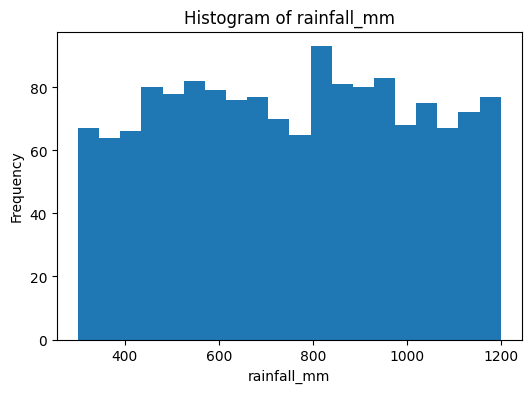

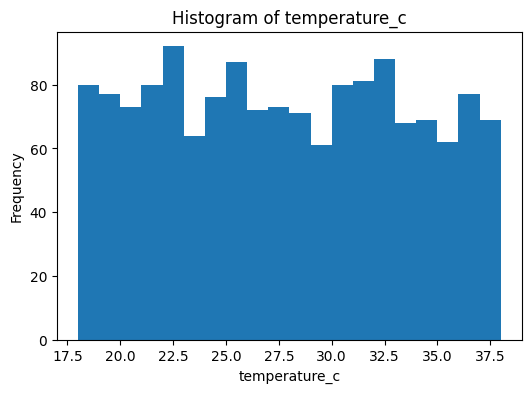

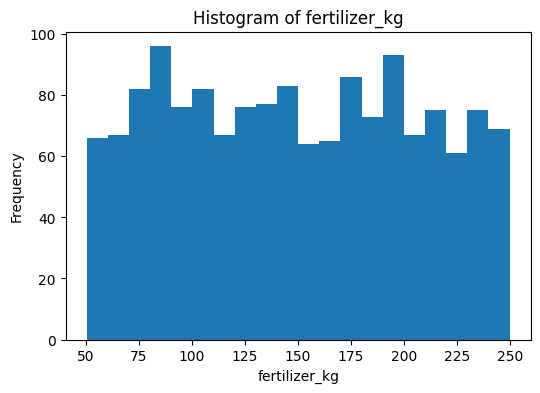

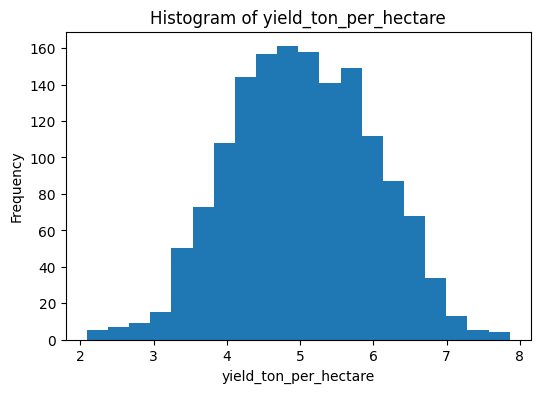

In [7]:
# Q4. Distribution Analysis
columns = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Crop Type Frequency:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


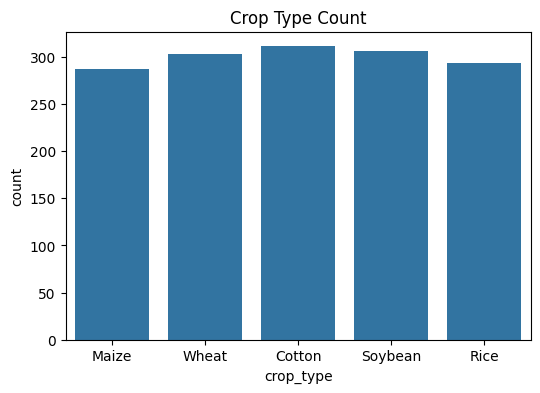

In [8]:
# Q5. Crop Type Analysis
print("\nCrop Type Frequency:")
print(df["crop_type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="crop_type", data=df)
plt.title("Crop Type Count")
plt.show()


Soil Type Frequency:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


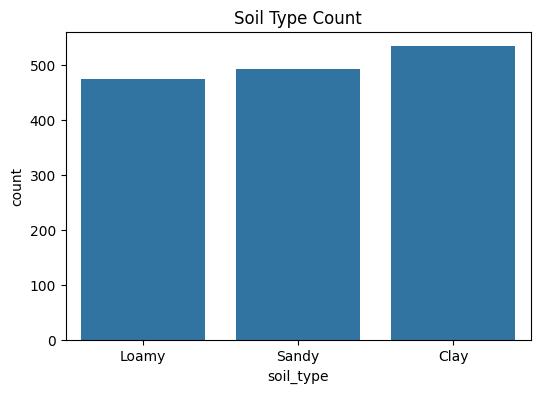

In [9]:
# Q6. Soil Type Analysis
print("\nSoil Type Frequency:")
print(df["soil_type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="soil_type", data=df)
plt.title("Soil Type Count")
plt.show()


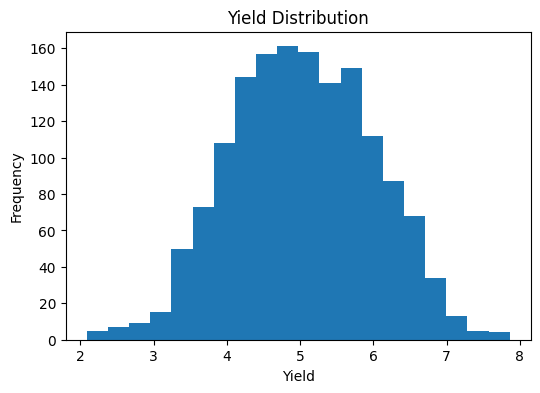

In [10]:
# Q7. Yield Distribution
plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

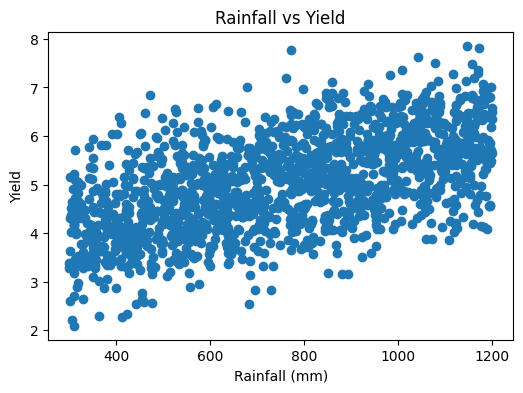

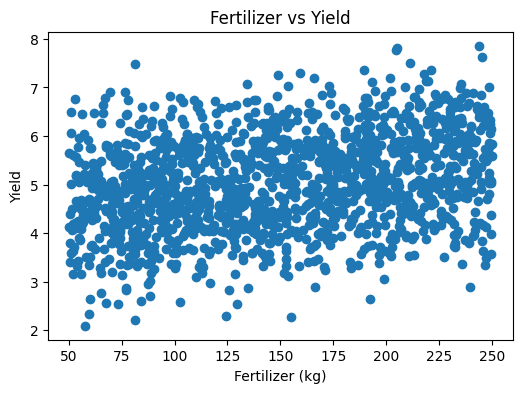

In [11]:
# Q8. Scatter Plot Analysis
plt.figure(figsize=(6,4))
plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()


Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

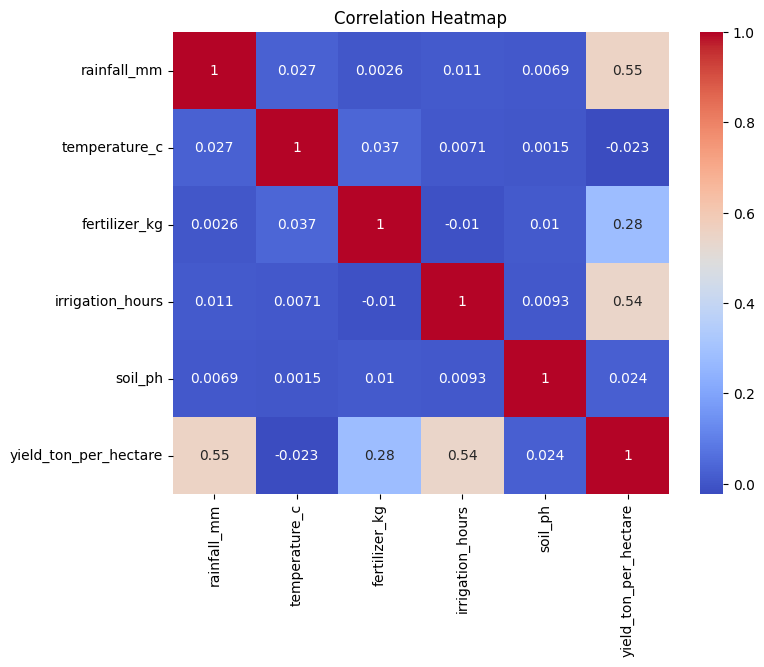


Correlation with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [12]:
# Q9. Correlation Analysis
corr_matrix = numeric_cols.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

yield_corr = corr_matrix["yield_ton_per_hectare"].sort_values(
    ascending=False
)

print("\nCorrelation with Yield:")
print(yield_corr)


In [13]:
# Q10. Group-Based Analysis
crop_avg = df.groupby("crop_type")[
    "yield_ton_per_hectare"
].mean()

soil_avg = df.groupby("soil_type")[
    "yield_ton_per_hectare"
].mean()

print("\nAverage Yield by Crop Type:")
print(crop_avg)

print("\nAverage Yield by Soil Type:")
print(soil_avg)



Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [14]:
# Q11. Feature Encoding
encoded_df = pd.get_dummies(
    df,
    columns=["crop_type", "soil_type"],
    drop_first=False
)

print("\nFirst 5 Rows After Encoding:")
print(encoded_df.head())


First 5 Rows After Encoding:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_

In [15]:
# Q12. Feature Selection
X = encoded_df.drop("yield_ton_per_hectare", axis=1)
y = encoded_df["yield_ton_per_hectare"]

print("\nInput Features (X):")
print(X.columns)

print("\nTarget Variable (y):")
print("yield_ton_per_hectare")


Input Features (X):
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type_Cotton', 'crop_type_Maize', 'crop_type_Rice',
       'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Clay',
       'soil_type_Loamy', 'soil_type_Sandy'],
      dtype='object')

Target Variable (y):
yield_ton_per_hectare


In [16]:
# Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Shapes:
X_train: (1200, 13)
X_test : (300, 13)
y_train: (1200,)
y_test : (300,)


In [17]:
# Q14. Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nIntercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nModel Coefficients:")
print(coef_df)

print("\nFeature with Highest Positive Coefficient:")
print(coef_df.iloc[0])


Intercept:
1.9111026182800726

Model Coefficients:
              Feature  Coefficient
7      crop_type_Rice     0.477369
11    soil_type_Loamy     0.365627
3    irrigation_hours     0.198327
8   crop_type_Soybean     0.095096
10     soil_type_Clay     0.062653
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
9     crop_type_Wheat    -0.038149
6     crop_type_Maize    -0.147693
5    crop_type_Cotton    -0.386623
12    soil_type_Sandy    -0.428280

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
